##Maximizar la función 𝑓(𝑥) = 𝑥 𝑠𝑒𝑛(10 𝜋 x) + 1, con 𝑥 ∈ [0,1].
En este codigo Tenemos una precisión que asignamos a 4 decimales; estableciendo las variables upper bound y lower bound como limite superior y limite inferior respectivamente.
Pop size equivale a la población.
Max gens es el número de generaciones, con una probabilidad de cruce de 90% y de mutación del 1%, escogiendo solo 5 individuos, de los que tienen la mejor aptitud.
La función aptitud se penaliza fuertemente si se pasa del rango, actualmente usamos 14 bits, pues la precisión de 4 decimales da.

Finalmente se colocaron 2 gráficas, 1- es como se va escogiendo a las mejores generaciones y la segunda gráfica es el punto en el que están los mejores hijos.



Usando 14 bits por cromosoma
Generación 10: Mejor fitness = 1.850594, x = 0.851248
Generación 20: Mejor fitness = 1.850595, x = 0.851187
Generación 30: Mejor fitness = 1.850595, x = 0.851187
Generación 40: Mejor fitness = 1.850595, x = 0.851187
Generación 50: Mejor fitness = 1.850595, x = 0.851187
Generación 60: Mejor fitness = 1.850595, x = 0.851187
Generación 70: Mejor fitness = 1.850595, x = 0.851187
Generación 80: Mejor fitness = 1.850595, x = 0.851187
Generación 90: Mejor fitness = 1.850595, x = 0.851187
Generación 100: Mejor fitness = 1.850595, x = 0.851187
Generación 110: Mejor fitness = 1.850595, x = 0.851187
Generación 120: Mejor fitness = 1.850595, x = 0.851187
Generación 130: Mejor fitness = 1.850595, x = 0.851187
Generación 140: Mejor fitness = 1.850595, x = 0.851187
Generación 150: Mejor fitness = 1.850595, x = 0.851187
Generación 160: Mejor fitness = 1.850595, x = 0.851187
Generación 170: Mejor fitness = 1.850595, x = 0.851187
Generación 180: Mejor fitness = 1.850595, x =

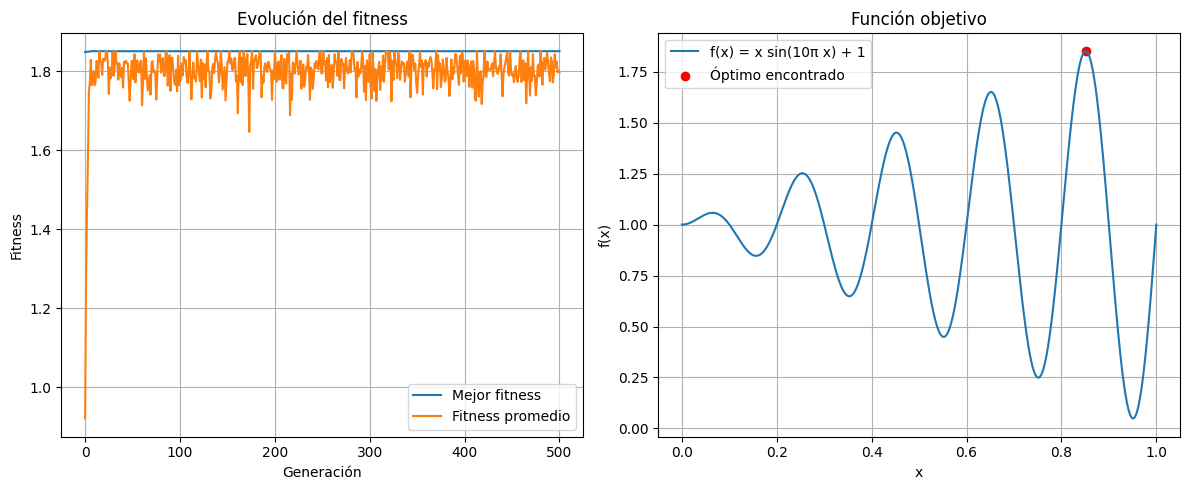

In [20]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros del problema
LOWER_BOUND = 0.0
UPPER_BOUND = 1.0
PRECISION = 4
NUM_BITS = int(np.ceil(np.log2((UPPER_BOUND - LOWER_BOUND) * 10**PRECISION + 1)))
print(f"Usando {NUM_BITS} bits por cromosoma")

POP_SIZE = 50
MAX_GENS = 500
PC = 0.9
PM = 0.01
ELITE_SIZE = 4  # número de mejores individuos que pasan directamente a la siguiente generación (elitismo)

# Función a maximizar
def f(x):
    return x * np.sin(10 * np.pi * x) + 1

# Decodificación: convierte un cromosoma binario (lista de 0/1) a un valor real en [0,1]
def decode(binary_chromosome):
    # binary_chromosome es una lista de bits (0/1) de longitud NUM_BITS
    decimal = 0
    for bit in binary_chromosome:
        decimal = (decimal << 1) | bit
    # Mapear al rango [LOWER_BOUND, UPPER_BOUND]
    max_val = 2**NUM_BITS - 1
    x = LOWER_BOUND + (UPPER_BOUND - LOWER_BOUND) * decimal / max_val
    return x

# Evaluación de la aptitud: devuelve el valor de f(x)
def fitness(chromosome):
    x = decode(chromosome)
    return f(x)

# Inicialización de la población: crea POP_SIZE cromosomas aleatorios
def initialize_population():
    population = []
    for _ in range(POP_SIZE):
        chromosome = [np.random.randint(0, 2) for _ in range(NUM_BITS)]
        population.append(chromosome)
    return population

# Selección por torneo (k=3) (también se puede usar ruleta, pero torneo es simple y efectivo)
def tournament_selection(population, fitness_values, k=3):
    selected = []
    for _ in range(POP_SIZE):
        # Elegir k individuos al azar
        candidates_idx = np.random.choice(len(population), k, replace=False)
        # Elegir el de mayor fitness
        best_idx = candidates_idx[np.argmax([fitness_values[i] for i in candidates_idx])]
        selected.append(population[best_idx])
    return selected

# Cruce en un punto
def crossover(parent1, parent2):
    if np.random.rand() < PC:
        point = np.random.randint(1, NUM_BITS)  # punto de cruce entre 1 y NUM_BITS-1
        child1 = parent1[:point] + parent2[point:]
        child2 = parent2[:point] + parent1[point:]
    else:
        child1, child2 = parent1[:], parent2[:]
    return child1, child2

# Mutación por bit
def mutate(chromosome):
    for i in range(NUM_BITS):
        if np.random.rand() < PM:
            chromosome[i] = 1 - chromosome[i]  # flip
    return chromosome

# Algoritmo genético principal
def genetic_algorithm():
    # Inicializar población
    population = initialize_population()
    best_fitness_history = []
    avg_fitness_history = []

    # Evaluar fitness inicial
    fitness_values = [fitness(chrom) for chrom in population]
    best_idx = np.argmax(fitness_values)
    best_fitness_history.append(fitness_values[best_idx])
    avg_fitness_history.append(np.mean(fitness_values))
    best_solution = population[best_idx]

    for generation in range(1, MAX_GENS + 1):
        # Aplicar elitismo: guardar los mejores ELITE_SIZE individuos
        elite_indices = np.argsort(fitness_values)[-ELITE_SIZE:]
        elite = [population[i][:] for i in elite_indices]  # copia

        # Selección (torneo)
        selected = tournament_selection(population, fitness_values)

        # Crear nueva población
        new_population = []
        # Rellenar con cruce y mutación
        while len(new_population) < POP_SIZE - ELITE_SIZE:
            # Elegir dos padres de la población seleccionada (con reemplazo)
            parent1 = selected[np.random.randint(0, POP_SIZE)]
            parent2 = selected[np.random.randint(0, POP_SIZE)]
            child1, child2 = crossover(parent1, parent2)
            child1 = mutate(child1)
            child2 = mutate(child2)
            new_population.append(child1)
            if len(new_population) < POP_SIZE - ELITE_SIZE:
                new_population.append(child2)

        # Añadir la élite
        new_population.extend(elite)

        # Reemplazar población
        population = new_population

        # Evaluar nuevos fitness
        fitness_values = [fitness(chrom) for chrom in population]
        best_idx = np.argmax(fitness_values)
        best_fitness_history.append(fitness_values[best_idx])
        avg_fitness_history.append(np.mean(fitness_values))
        best_solution = population[best_idx]

        # Mostrar progreso cada 10 generaciones
        if generation % 10 == 0:
            print(f"Generación {generation}: Mejor fitness = {fitness_values[best_idx]:.6f}, x = {decode(best_solution):.6f}")

    # Resultado final
    best_x = decode(best_solution)
    best_f = fitness(best_solution)
    return best_x, best_f, best_fitness_history, avg_fitness_history

# Ejecutar el AG
best_x, best_f, best_history, avg_history = genetic_algorithm()
print(f"\nMejor solución encontrada: x = {best_x:.6f}, f(x) = {best_f:.6f}")

# Graficar la evolución del fitness
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(best_history, label='Mejor fitness')
plt.plot(avg_history, label='Fitness promedio')
plt.xlabel('Generación')
plt.ylabel('Fitness')
plt.title('Evolución del fitness')
plt.legend()
plt.grid(True)

# Graficar la función y el punto óptimo encontrado
plt.subplot(1, 2, 2)
x_vals = np.linspace(0, 1, 1000)
y_vals = f(x_vals)
plt.plot(x_vals, y_vals, label='f(x) = x sin(10π x) + 1')
plt.scatter(best_x, best_f, color='red', label='Óptimo encontrado')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Función objetivo')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()